In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from joblib import dump
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

/var/folders/gj/vcd70mqn3gx_kgbx262jgt6m0000gn/T/ipykernel_64837/321278326.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


1 - Préparation des données

In [3]:
data = pd.read_csv("export_IA.csv")
print(data.head()) 

   Unnamed: 0   id       MMSI         BaseDateTime       LAT       LON   SOG  \
0           1   82  636017833  2023-05-29 00:00:06  29.07019 -89.29958  13.4   
1           3   91  367477280  2023-05-29 00:00:06  29.25456 -89.97235   0.0   
2           6  119  366954420  2023-05-29 00:00:10  27.77637 -82.63027   0.0   
3          11  222  367670000  2023-05-29 00:00:05  29.13941 -90.20319   0.0   
4          13  255  255805583  2023-05-29 00:00:02  28.86110 -95.15923   0.1   

     COG  Heading        VesselName         IMO CallSign  VesselType  Status  \
0  227.6      227       STOLT LOTUS  IMO9617648    D5MX5          80       0   
1  267.4      511              HERO  IMO8964147  WDH2114          60       0   
2  265.3      294  PROVINCETOWN III  IMO9329394  WDB8185          60       0   
3  165.1      340    HARVEY AMERICA  IMO9688477     KHAI          70       0   
4   39.9       64        CHEM SEA 1  IMO9731729     CQTD          80       1   

   Length  Width  Draft  Cargo Transce

Etude des corrélations

/var/folders/gj/vcd70mqn3gx_kgbx262jgt6m0000gn/T/ipykernel_64837/490819588.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cor_with_target.values, y=cor_with_target.index, palette="coolwarm")


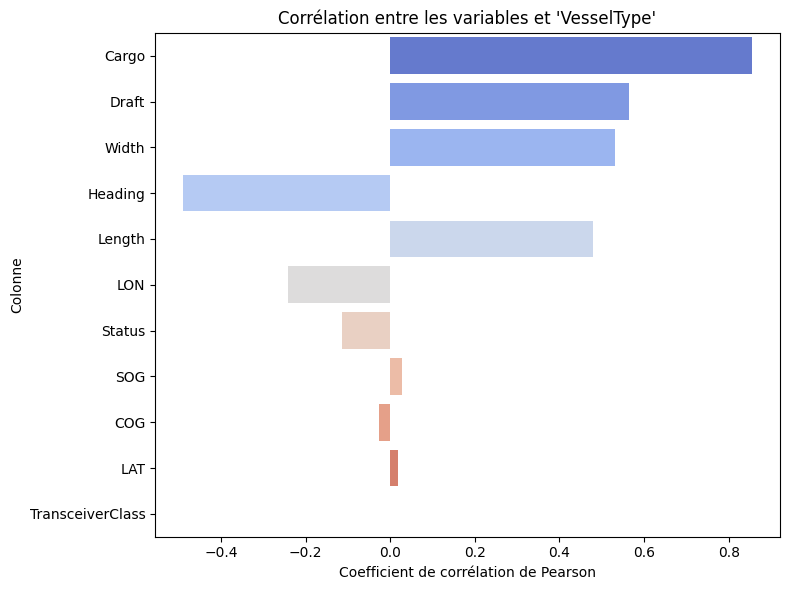

In [4]:
cols_to_drop = ['Unnamed: 0', 'id', 'MMSI', 'BaseDateTime', 'VesselName', 'IMO', 'CallSign']
data_clean = data.drop(columns=cols_to_drop)

data_clean['TransceiverClass'] = pd.factorize(data_clean['TransceiverClass'])[0]

correlation_matrix = data_clean.corr(numeric_only=True)

cor_with_target = correlation_matrix['VesselType'].drop('VesselType').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=cor_with_target.values, y=cor_with_target.index, palette="coolwarm")
plt.title("Corrélation entre les variables et 'VesselType'")
plt.xlabel("Coefficient de corrélation de Pearson")
plt.ylabel("Colonne")
plt.tight_layout()
plt.show() 

Preparation des données pour l'apprentissage

In [ ]:
data2 = pd.DataFrame(data, columns= ["VesselType", "Length", "Width", "Draft", "Cargo", "SOG", "COG", "Status"]) 
print(data2.head()) 
print(data2.dtypes) # Pas de types str, uniquement float ou int

# encodage de la colonne Status 
encoder = LabelEncoder()
data2['Status'] = encoder.fit_transform(data2['Status'])
dump(encoder, 'encoder.pkl')

# séparation features et la cible à prédire
X_1 = data2.drop('VesselType', axis=1) # features sans VesselType
y_1 = data2['VesselType'] # cible => uniquement VesselType

numeric_cols = ["Length", "Width", "Draft", "Cargo", "SOG", "COG"] # colonnes avec des données numériques

# normalisation des données numériques
scaler = StandardScaler()
X_1[numeric_cols] = scaler.fit_transform(X_1[numeric_cols])
dump(scaler, 'scaler.pkl') 

# séparation en base d'apprentissage et de test
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42, stratify=y_1)

# regler le déséquilibre des classes 
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_1, y_train_1)
X_test, y_test = smote.fit_resample(X_test_1, y_test_1)

# visualisation des données après préparation
print(X_test.head())
print(X_train.head()) 


   VesselType  Length  Width  Draft  Cargo   SOG    COG  Status
0          80     183     28   10.0     83  13.4  227.6       0
1          60      47      9    2.3     60   0.0  267.4       0
2          60      30      9    1.9     60   0.0  265.3       0
3          70      92     20    5.0     70   0.0  165.1       0
4          80     160     25    6.5     80   0.1   39.9       1
VesselType      int64
Length          int64
Width           int64
Draft         float64
Cargo           int64
SOG           float64
COG           float64
Status          int64
dtype: object
     Length     Width     Draft     Cargo       SOG       COG  Status
0 -1.395276 -0.771151 -1.618952 -1.701137 -0.667845  0.334431       4
1 -0.494769 -0.688904 -0.677287  0.673587 -0.667845 -0.849590       1
2 -1.491330 -1.017891 -1.364448 -1.701137 -0.685321  1.277829       0
3  0.886010  1.120521  0.213478  0.673587  1.376885 -0.178326       0
4  0.225637  0.298055  1.053341 -0.513775 -0.667845 -0.197423       1
     L

2 - Classification

On essaye plusieurs modèle d'apprentissage supervisée pour la classification afin de determiner les plus adapté. La méthode d'apprentissage, de test du modèle et d'évaluations des paramètres est similaire pour chaque méthode.

Random Forest

              precision    recall  f1-score   support

          60       1.00      1.00      1.00     17814
          61       1.00      1.00      1.00     17814
          70       1.00      1.00      1.00     17814
          71       1.00      1.00      1.00     17814
          74       1.00      1.00      1.00     17814
          79       1.00      1.00      1.00     17814
          80       1.00      1.00      1.00     17814
          82       1.00      1.00      1.00     17814
          84       1.00      1.00      1.00     17814
          89       1.00      1.00      1.00     17814

    accuracy                           1.00    178140
   macro avg       1.00      1.00      1.00    178140
weighted avg       1.00      1.00      1.00    178140



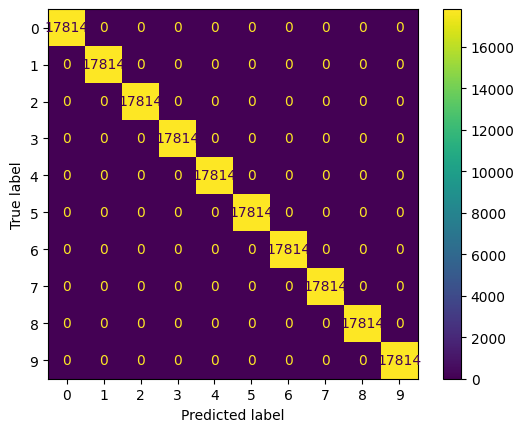

In [ ]:
model = RandomForestClassifier(random_state=42, class_weight="balanced")
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred)) # => renvoi: précision, recall, f1-score, support, accuracy et average

# affichage matrice de confusion pour évaluer le modèle
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot()
plt.show()

Recherche meilleurs paramètres pour RandomForest

In [26]:
param_grid = {'n_estimators': [100, 200], # paramètres 'standard' pour le modèle
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5]}

random_search = RandomizedSearchCV(model, param_distributions=param_grid, # test aléatoirement en fonction des paramètres données (10 itérations) 
                                   n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
print(f"Meilleur score pour RandomForest : {random_search.best_score_:.4f}")
print(f"Meilleurs paramètres : {random_search.best_params_}") 
# => renvoi (les resultats peuvent varier car présence d'aléatoire et il n'existe pas qu'une seule combinaison performants): 
# Meilleur score pour RandomForest : 1.0000
# Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}

Meilleur score pour RandomForest : 1.0000
Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}


In [27]:
param_grid_fine = {'n_estimators': [50, 100, 150], # parametre affinés par rapport aux premiers resultats
                   'max_depth': [15, 20, 25],
                   'min_samples_split': [3, 7]}

random_search = RandomizedSearchCV(model, param_distributions=param_grid_fine, 
                                   n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
print(f"Meilleur score pour RandomForest : {random_search.best_score_:.4f}")
print(f"Meilleurs paramètres : {random_search.best_params_}")
# => renvoi: 
#Meilleur score pour RandomForest : 1.0000
#Meilleurs paramètres : {'n_estimators': 50, 'min_samples_split': 3, 'max_depth': 15}

Meilleur score pour RandomForest : 1.0000
Meilleurs paramètres : {'n_estimators': 50, 'min_samples_split': 3, 'max_depth': 15}


SVM

              precision    recall  f1-score   support

          60       1.00      0.97      0.99     17814
          61       0.97      1.00      0.99     17814
          70       1.00      0.98      0.99     17814
          71       1.00      1.00      1.00     17814
          74       1.00      1.00      1.00     17814
          79       1.00      1.00      1.00     17814
          80       0.98      1.00      0.99     17814
          82       1.00      1.00      1.00     17814
          84       1.00      1.00      1.00     17814
          89       1.00      1.00      1.00     17814

    accuracy                           1.00    178140
   macro avg       1.00      1.00      1.00    178140
weighted avg       1.00      1.00      1.00    178140



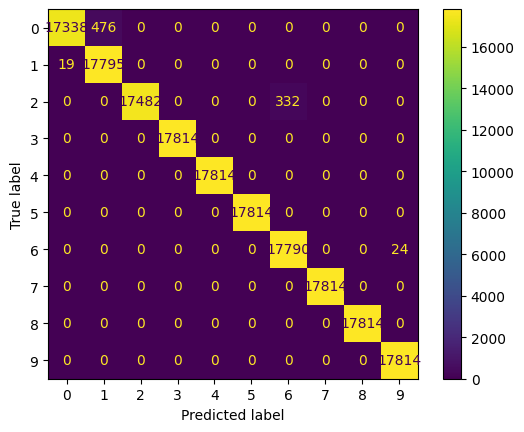

In [32]:
model = SVC(random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot()
plt.show()

Recherche meilleurs paramètres pour SVM

In [ ]:
param_grid = {'C': [0.1, 1, 10],
              'kernel': ['rbf', 'linear']}

random_search = RandomizedSearchCV(model, param_distributions=param_grid, 
                                   n_iter=6, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
print(f"Meilleur score pour SVM : {random_search.best_score_:.4f}")
print(f"Meilleurs paramètres : {random_search.best_params_}")
# Meilleur score pour SVM : 0.9960
# Meilleurs paramètres : {'kernel': 'rbf', 'C': 10}

Meilleur score pour RandomForest : 0.9960
Meilleurs paramètres : {'kernel': 'rbf', 'C': 10}


Gradient boosting

              precision    recall  f1-score   support

          60       1.00      1.00      1.00     17814
          61       1.00      1.00      1.00     17814
          70       1.00      1.00      1.00     17814
          71       1.00      1.00      1.00     17814
          74       1.00      1.00      1.00     17814
          79       1.00      1.00      1.00     17814
          80       1.00      1.00      1.00     17814
          82       1.00      1.00      1.00     17814
          84       1.00      1.00      1.00     17814
          89       1.00      1.00      1.00     17814

    accuracy                           1.00    178140
   macro avg       1.00      1.00      1.00    178140
weighted avg       1.00      1.00      1.00    178140



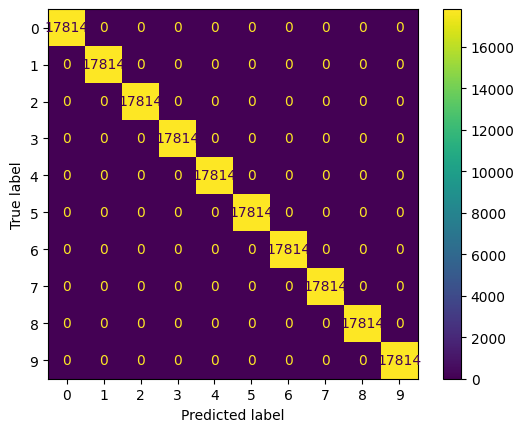

In [29]:
model = GradientBoostingClassifier(random_state=42) 
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot()
plt.show()

Recherche meilleurs paramètres pour Gradient Boosting

In [94]:
param_grid = {'n_estimators': [100, 150],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]}

random_search = RandomizedSearchCV(model, param_distributions=param_grid, 
                                   n_iter=8, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
print(f"Meilleur score pour GradientBoostingClassifier : {random_search.best_score_:.4f}")
print(f"Meilleurs paramètres : {random_search.best_params_}") 
# Meilleur score pour GradientBoostingClassifier : 1.0000
# Meilleurs paramètres : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}

Meilleur score pour GradientBoostingClassifier : 1.0000
Meilleurs paramètres : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


KNN

              precision    recall  f1-score   support

          60       1.00      1.00      1.00     17814
          61       1.00      1.00      1.00     17814
          70       1.00      1.00      1.00     17814
          71       1.00      1.00      1.00     17814
          74       1.00      1.00      1.00     17814
          79       1.00      1.00      1.00     17814
          80       1.00      1.00      1.00     17814
          82       1.00      1.00      1.00     17814
          84       1.00      1.00      1.00     17814
          89       1.00      1.00      1.00     17814

    accuracy                           1.00    178140
   macro avg       1.00      1.00      1.00    178140
weighted avg       1.00      1.00      1.00    178140



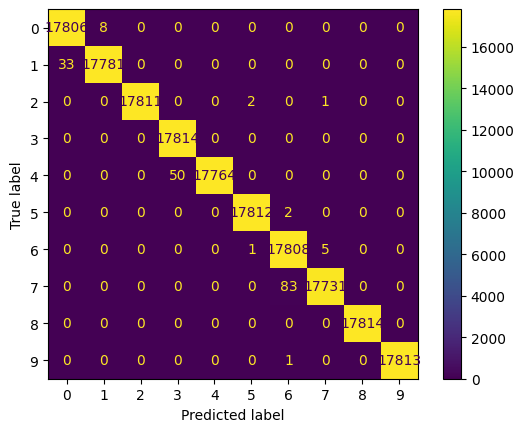

In [30]:
model = KNeighborsClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot()
plt.show()

Recherche meilleurs paramètres pour KNeighborsClassifier

In [97]:
param_grid = {'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']}

random_search = RandomizedSearchCV(model, param_distributions=param_grid, 
                                   n_iter=6, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
print(f"Meilleur score pour KNeighborsClassifier : {random_search.best_score_:.4f}")
print(f"Meilleurs paramètres : {random_search.best_params_}")
# Meilleur score pour KNeighborsClassifier : 0.9996
# Meilleurs paramètres : {'weights': 'distance', 'n_neighbors': 3}

Meilleur score pour KNeighborsClassifier : 0.9996
Meilleurs paramètres : {'weights': 'distance', 'n_neighbors': 3}


Modèle choisi : Gradient Boosting ou Random Forest (même précision).
On choisi RandomForest (éxecution plus rapide et recherche de paramètres plus approfondi)

Vérification du modèle avec les bons paramètres: 

In [31]:
model_final = RandomForestClassifier(n_estimators=50, min_samples_split=3, max_depth=15, random_state=42, class_weight="balanced")

scores = cross_val_score(model_final, X_train, y_train, cv=5)

print(f"Scores de validation croisée : {scores}")
print(f"Précision moyenne : {scores.mean():.2f}")

skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(model_final, X_train, y_train, cv=skf)
print(scores.mean()) 

Scores de validation croisée : [1. 1. 1. 1. 1.]
Précision moyenne : 1.00
1.0


Préparation et export final du modèle: 

In [21]:
model_final = RandomForestClassifier(n_estimators=50, min_samples_split=3, max_depth=15, random_state=42, class_weight="balanced")
model_final.fit(X_train,y_train) 

dump(model_final, "model.pkl") 

['model.pkl']